In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [58]:
df = pd.read_csv('../materials/rfm_data_orders.rda.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4906 entries, 0 to 4905
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   4906 non-null   int64
 1   customer_id  4906 non-null   str  
 2   order_date   4906 non-null   str  
 3   revenue      4906 non-null   int64
 4   first_name   4906 non-null   str  
 5   last_name    4906 non-null   str  
 6   email        4906 non-null   str  
dtypes: int64(2), str(5)
memory usage: 558.8 KB
None


In [59]:
# df.head()
df

,Unnamed: 0,customer_id,order_date,revenue,first_name,last_name,email
0,0,Brion Stark,2004-12-20,32,Brion,Stark,brion_stark@rfmail.com
1,1,Ethyl Botsford,2005-05-02,36,Ethyl,Botsford,ethyl_botsford@rfmail.com
2,2,Hosteen Jacobi,2004-03-06,116,Hosteen,Jacobi,hosteen_jacobi@rfmail.com
3,3,Edw Frami,2006-03-15,99,Edw,Frami,edw_frami@rfmail.com
4,4,Josef Lemke,2006-08-14,76,Josef,Lemke,josef_lemke@rfmail.com
...,...,...,...,...,...,...,...
4901,4901,Lovie Keeling,2006-07-22,78,Lovie,Keeling,lovie_keeling@rfmail.com
4902,4902,Malaya White,2005-10-31,83,Malaya,White,malaya_white@rfmail.com
4903,4903,Charity Rodriguez,2004-07-04,109,Charity,Rodriguez,charity_rodriguez@rfmail.com
4904,4904,Demetric Franecki,2006-04-29,101,Demetric,Franecki,demetric_franecki@rfmail.com


In [60]:
df.shape
df.describe()

,Unnamed: 0,revenue
count,4906.000000,4906.000000
mean,2452.500000,94.610273
std,1416.384541,57.827010
min,0.000000,10.000000
25%,1226.250000,45.000000
50%,2452.500000,81.000000
75%,3678.750000,137.000000
max,4905.000000,219.000000


In [61]:
# Drop first column
# df = df.iloc[:, 1:]
# df

### Data quality checks

`customer_id` is actually the customer's full name.

In [62]:
df.rename(columns={'customer_id': 'customer_name'}, inplace=True)

In [63]:
print("missing values per column:")
print(df.isna().sum(), "\n")

print("duplicated rows:", df.duplicated().sum())

print("\nUnique customers:", df['customer_name'].nunique())
print("Unique emails:", df['email'].nunique())

missing values per column:
Unnamed: 0       0
customer_name    0
order_date       0
revenue          0
first_name       0
last_name        0
email            0
dtype: int64 

duplicated rows: 0

Unique customers: 995
Unique emails: 995


### Date & order transaction volume 

Date range: 2001-10-29 00:00:00 to 2006-12-30 00:00:00
Num days: 1888


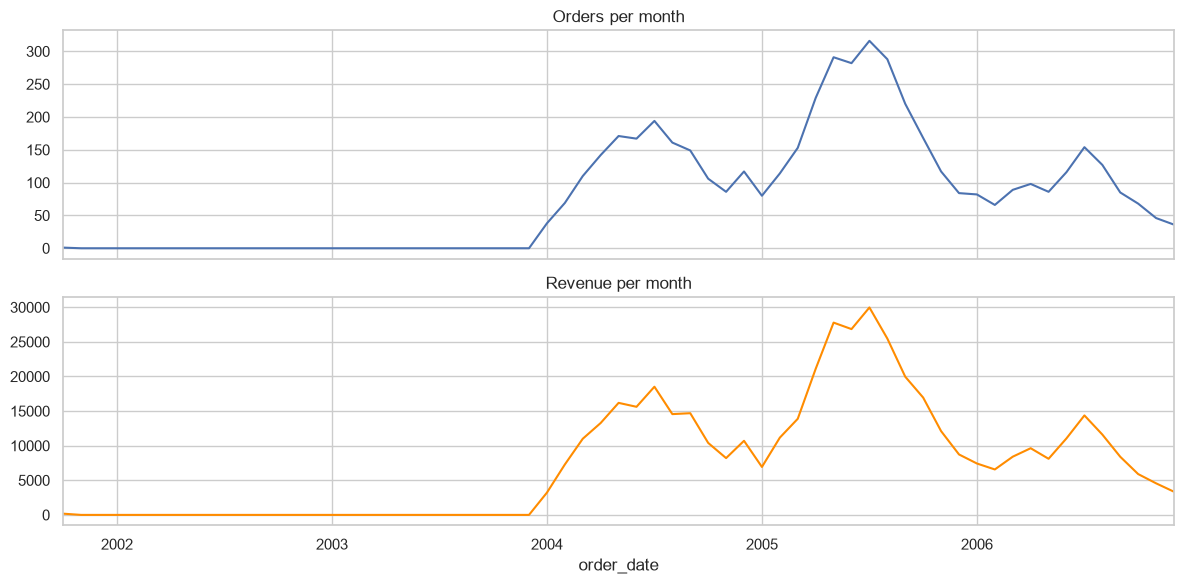

In [64]:
df['order_date'] = pd.to_datetime(df['order_date'])

print("Date range:", df['order_date'].min(), "to", df['order_date'].max())
print("Num days:", (df['order_date'].max() - df['order_date'].min()).days)

monthly = df.set_index('order_date').resample('MS').agg(orders=('revenue', 'size'), revenue=('revenue', 'sum'))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
monthly['orders'].plot(ax=axes[0], title='Orders per month')
monthly['revenue'].plot(ax=axes[1], title='Revenue per month', color='darkorange')
plt.tight_layout()
plt.show()

### Per-customer behavior 

look at the raw distributions, for each customer: /
 - how much they order
 - how much for each order /
 - customer spending/revenue /
 - number of days since last order

In [65]:
max_date = df['order_date'].max() + pd.Timedelta(days=1) # Add one day, so each customer has at least 1 day of recency

customer_summary = df.groupby('customer_name').agg(
    frequency=('order_date', 'size'), # num order made by customer
    monetary=('revenue', 'sum'), # sum of revenue per customer
    avg_order_value=('revenue', 'mean'), # average revenue per order for each customer
    last_purchase=('order_date', 'max'),
).reset_index()
customer_summary['recency_days'] = (max_date - customer_summary['last_purchase']).dt.days
customer_summary

,customer_name,frequency,monetary,avg_order_value,last_purchase,recency_days
0,Abbey O'Reilly,6,472,78.666667,2006-06-09,205
1,Add Senger,3,340,113.333333,2006-08-13,140
2,Aden Lesch,4,405,101.250000,2006-06-20,194
3,Aden Murphy,7,596,85.142857,2006-09-24,98
4,Admiral Senger,5,448,89.600000,2006-08-21,132
...,...,...,...,...,...,...
990,Zechariah Gislason,9,1196,132.888889,2006-06-07,207
991,Zenas Pacocha,4,442,110.500000,2005-11-21,405
992,Zeno Lakin,1,38,38.000000,2005-07-25,524
993,Zillah Koch,4,516,129.000000,2005-07-01,548


In [66]:
print("Snapshot date used for recency:", max_date.date())
customer_summary[['frequency', 'monetary', 'avg_order_value', 'recency_days']].describe()

Snapshot date used for recency: 2006-12-31


,frequency,monetary,avg_order_value,recency_days
count,995.000000,995.000000,995.000000,995.000000
mean,4.930653,466.490452,94.631530,286.738693
std,2.203942,240.634759,29.556586,194.489928
min,1.000000,12.000000,12.000000,1.000000
25%,3.000000,285.500000,76.598214,132.000000
50%,5.000000,436.000000,93.500000,229.000000
75%,6.000000,620.000000,111.171429,445.500000
max,14.000000,1488.000000,219.000000,976.000000


- average customer buy our product for a few times.  
- average customer have not order anything for last 200+ days. \
this data is 5 years, and each customer buy few times, so the recency gap might be normal.

### Relationships & Correlation between R, F, M

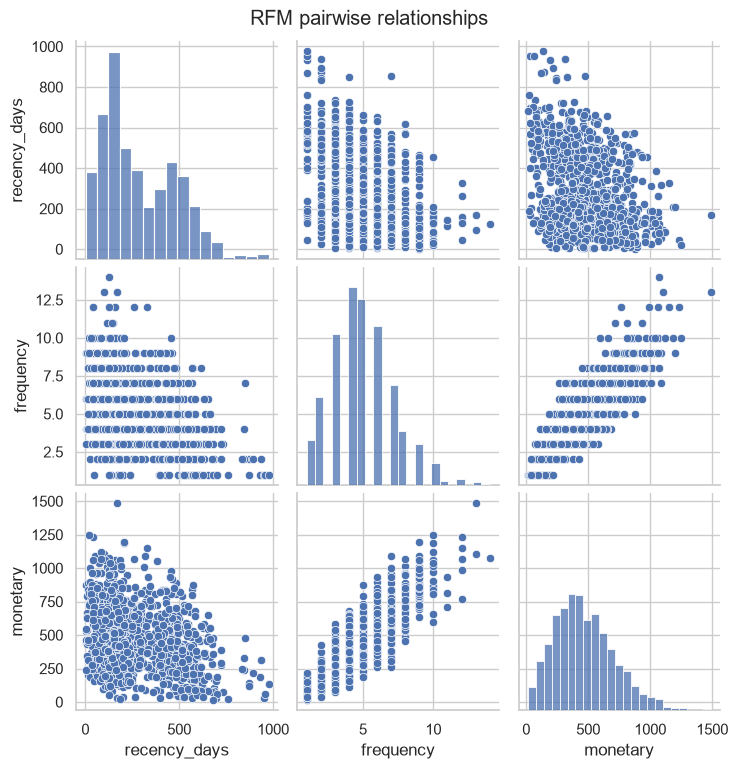

,recency_days,frequency,monetary
recency_days,1.000000,-0.380210,-0.302697
frequency,-0.380210,1.000000,0.857731
monetary,-0.302697,0.857731,1.000000


In [67]:
rfm_cols = ['recency_days', 'frequency', 'monetary']

sns.pairplot(customer_summary[rfm_cols])
plt.suptitle('RFM pairwise relationships', y=1.02)
plt.show()

customer_summary[rfm_cols].corr()

## Findings summary

- 4,906 transactions, 995 unique customers, date from 2001-10-29 to 2006-12-30, no missing values or duplicate rows.
- Revenue per order ranges ~$10-$219 (avg ~$95); frequency ranges 1-14 orders/customer (avg ~4.9); recency spans 1-976 days as of the 2006-12-31.
- Recency, frequency, and monetary are all right-skewed (skew 0.56-0.70) — candidates for log-transform before scaling/clustering.
- **Frequency and monetary are highly correlated (r=0.86)** — the two carry overlapping signal, so raw 3-feature K-Means may effectively cluster on ~2 independent axes (recency vs. spend-frequency). This is a concrete point for the comparative analysis: an autoencoder can learn a non-linear embedding that may separate customers the correlated raw features can't, which is worth calling out when comparing ML vs. DL results.
- Next step: RFM feature engineering (recency/frequency/monetary scores + transforms) feeding into the ML (K-Means/DBSCAN) and DL (autoencoder) clustering approaches.